In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
from scipy.optimize import linear_sum_assignment
from tqdm.contrib.concurrent import process_map
import networkx as nx
import random
import heapq

In [2]:
ts_df = pd.read_csv("./data/tracks.txt", sep="\t")
# ts_df = pd.read_csv("./data/normalized_pretwitch.csv")
t_threshold = 248
xyz_scale = 0.1625
# xyz_scale = 1
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
cell_names = ts_df["name"].unique()
valid_cell_names = []
newborn_cells = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        newborn_cells.append(name)
        continue
    valid_cell_names.append(name)

lineage_exp = pd.read_csv("data/protein/aggregated_all/s3.csv", index_col=0).T
# lineage_exp = pd.read_csv("data/protein/aggregated_all/s3_lineage_umap_embedding_3d.csv", index_col=0)
# lineage_exp = pd.read_csv("data/protein/aggregated_all/binned_tenth_lineage_adj_expression.csv", index_col=0)
# fill NaN values with 0
lineage_exp = lineage_exp.fillna(0)


In [3]:

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

untracked_nodes = ["AB", "P0", "P1"]

first_internal_layer = ["ABa", "ABp", "EMS", "P2"]

In [4]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [5]:
class Node:
    def __init__(self, key, coordinate, exp_data=None):
        self.key = key
        self.coordinate = coordinate
        self.exp_data = exp_data if exp_data is not None else lineage_exp[key].values
        self.children = []
        self.optimized = False
        self.parent = None
        self.is_terminal = False
        self.to_prune = False
        self.is_top = False
        self.depth = -1


In [6]:
terminal_nodes = []
internal_front = []
internal_pool = []
cutoff_terminal_nodes = []
coordinate_map = {}
exp_data_map = {}
all_lineage_names = []
depth_group = defaultdict(list)
def dfs(node, terminal_nodes, depth):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if lookup_name in valid_cell_names or lookup_name in untracked_nodes:
        all_lineage_names.append(lookup_name)
        if lookup_name in valid_cell_names:
            coordinate = ts_df.loc[ts_df['name'] == lookup_name].values[-1][1:4]*xyz_scale
            if lookup_name in lineage_exp.columns:
                exp_data = lineage_exp[lookup_name].values
            else:
                print(f"Warning: {lookup_name} not found in lineage expression data.")
                exp_data = np.zeros(lineage_exp.shape[0])
        else:
            coordinate = np.array([0, 0, 0])
            exp_data = np.zeros(lineage_exp.shape[0])
        tree_node = Node(lookup_name, coordinate, exp_data)
        tree_node.depth = depth
        coordinate_map[lookup_name] = coordinate
        exp_data_map[lookup_name] = exp_data
        for child in children:
            child_node = dfs(child, terminal_nodes, depth+1)
            if child_node:
                child_node.parent = tree_node
                tree_node.children.append(child_node)
        if len(children) == 0:
            terminal_nodes.append(tree_node)
            tree_node.is_terminal = True
            tree_node.optimized = True
            depth_group[depth].append(tree_node)
            return tree_node
        if lookup_name in first_internal_layer:
            internal_front.append(tree_node)
        if lookup_name in untracked_nodes:
            tree_node.optimized = True
            tree_node.is_top = True
        elif lookup_name not in untracked_nodes and len(tree_node.children) > 0:
            internal_pool.append(tree_node.key)
        elif len(tree_node.children) == 0:
            cutoff_terminal_nodes.append(tree_node)
            tree_node.optimized = True
            tree_node.is_terminal = True
        depth_group[depth].append(tree_node)
        return tree_node
    else:
        return None

root = dfs(lineage_data, terminal_nodes, 0)
terminal_nodes_names = [node.key for node in terminal_nodes]

In [7]:
cost_q = deque(internal_front)
lineage_xyz_cost = 0
lineage_exp_cost = 0
count = 0
while len(cost_q) > 0:
    cur_node = cost_q.popleft()
    for child in cur_node.children:
        cost_q.append(child)
        # if cur_node.optimized:
        #     continue
        lineage_xyz_cost += np.linalg.norm(cur_node.coordinate - child.coordinate)
        lineage_exp_cost += np.linalg.norm(cur_node.exp_data - child.exp_data)
        count += 1
print(count)
print(lineage_xyz_cost, lineage_exp_cost)

1008
4495.134160709496 114615.825926351


In [8]:
all_terminal_nodes = terminal_nodes + cutoff_terminal_nodes
all_terminal_nodes_names = [node.key for node in all_terminal_nodes]
all_nodes = all_terminal_nodes_names + internal_pool
all_nodes_coordinates = np.array([coordinate_map[name] for name in all_nodes])
all_nodes_exp_data = np.array([exp_data_map[name] for name in all_nodes])

In [9]:
death_time_list = []
dead_cells = []
for node_name in all_terminal_nodes_names:
    ts_data = ts_df[ts_df['name'] == node_name]
    last_time = ts_data['t'].values[-1] if not ts_data.empty else None
    if last_time != 280: 
        dead_cells.append(node_name)
        death_time_list.append(last_time)

In [10]:
all_nodes_idx = list(range(len(all_nodes)))
all_terminal_idx = [idx for idx in range(len(all_terminal_nodes))]
all_internal_idx = [idx for idx in range(len(all_terminal_nodes), len(all_terminal_nodes) + len(internal_pool))]
all_internal_front_idx = [all_nodes.index(node.key) for node in internal_front]
all_internal_pool_idx = list(set(all_internal_idx) - set(all_internal_front_idx))

In [11]:
all_xyz_cost_map = defaultdict(dict)
all_exp_cost_map = defaultdict(dict)
for node_i in all_nodes:
    for node_j in all_nodes:
        if node_i == node_j:
            all_xyz_cost_map[node_i][node_j] = 0
            all_exp_cost_map[node_i][node_j] = 0
            continue
        all_xyz_cost_map[node_i][node_j] = np.linalg.norm(coordinate_map[node_i] - coordinate_map[node_j])
        all_exp_cost_map[node_i][node_j] = np.linalg.norm(exp_data_map[node_i] - exp_data_map[node_j])


all_xyz_cost_mat = np.zeros((len(all_nodes), len(all_nodes)))
all_exp_cost_mat = np.zeros((len(all_nodes), len(all_nodes)))
for i, node_i in enumerate(all_nodes):
    for j, node_j in enumerate(all_nodes):
        if node_i == node_j:
            all_xyz_cost_mat[i][j] = 0
            all_exp_cost_mat[i][j] = 0
        else:
            all_xyz_cost_mat[i][j] = all_xyz_cost_map[node_i][node_j]
            all_exp_cost_mat[i][j] = all_exp_cost_map[node_i][node_j]

In [12]:
def random_build(seed):
    random.seed(seed)
    parent_pool = []
    child_pool = all_internal_pool_idx.copy()
    for idx in all_internal_front_idx:
        parent_pool.append(idx)
        parent_pool.append(idx)

    total_xyz_cost = 0
    total_exp_cost = 0
    edge_count = 0
    while child_pool:
        parent_idx = random.randint(0, len(parent_pool) - 1)
        child_idx = random.randint(0, len(child_pool) - 1)
        total_xyz_cost += np.linalg.norm(all_nodes_coordinates[parent_idx] - all_nodes_coordinates[child_idx])
        total_exp_cost += np.linalg.norm(all_nodes_exp_data[parent_idx] - all_nodes_exp_data[child_idx])
        parent_pool.pop(parent_idx)
        parent_pool.append(child_pool[child_idx])
        parent_pool.append(child_pool[child_idx])
        child_pool.pop(child_idx)
        edge_count += 1

    random.shuffle(parent_pool)
    for i in all_terminal_idx:
        total_xyz_cost += np.linalg.norm(all_nodes_coordinates[i] - all_nodes_coordinates[parent_pool[i]])
        total_exp_cost += np.linalg.norm(all_nodes_exp_data[i] - all_nodes_exp_data[parent_pool[i]])
    edge_count += len(all_terminal_idx)
    return total_xyz_cost, total_exp_cost, edge_count



In [15]:
random_cost_list = process_map(
    random_build, 
    range(1000000), 
    max_workers=20, 
    chunksize=100
)
random_xyz_costs = [cost[0] for cost in random_cost_list]
random_exp_costs = [cost[1] for cost in random_cost_list]
print(np.mean(random_xyz_costs), np.mean(random_exp_costs))
print(np.std(random_xyz_costs), np.std(random_exp_costs))

  0%|          | 0/1000000 [00:00<?, ?it/s]

17735.07730477906 221561.87416075074
231.86830815566896 2052.8032798011873


In [16]:
(lineage_xyz_cost - np.mean(random_xyz_costs)) / np.std(random_xyz_costs), \
(lineage_exp_cost - np.mean(random_exp_costs)) / np.std(random_exp_costs)  

(np.float64(-57.10113317935925), np.float64(-52.097563018682145))

In [44]:
# bottom-up optimization layer by layer
def pareto_optimization(idx):
    alpha = 0 + 0.001 * idx  # weight for xyz cost
    optimization_pool = all_internal_pool_idx.copy() + all_internal_front_idx.copy()
    optimization_pool = [all_nodes[i] for i in optimization_pool]
    for depth in sorted(depth_group.keys(), reverse=True)[:-3]:
        optimize_q = depth_group[depth]
        parents_dict = {}
        next_front = []
        parents = []
        for node in optimize_q:
            if node.parent.key in parents_dict:
                parents_dict[node.parent.key].append(node.key)
            else:
                parents_dict[node.parent.key] = [node.key]
                parents.append(node.parent.key)
                next_front.append(node.parent)

        xyz_cost_mat = np.zeros((len(optimization_pool), len(parents)))
        exp_cost_mat = np.zeros((len(optimization_pool), len(parents)))
        for i in range(len(optimization_pool)):
            for j in range(len(parents)):
                for child in parents_dict[parents[j]]:
                    xyz_cost_mat[i][j] += np.linalg.norm(coordinate_map[optimization_pool[i]] - coordinate_map[child])
                    exp_cost_mat[i][j] += np.linalg.norm(exp_data_map[optimization_pool[i]] - exp_data_map[child])
        cost_mat = alpha * xyz_cost_mat + (1 - alpha) * exp_cost_mat
        row_indices, col_indices = linear_sum_assignment(cost_mat)
        for row, col in zip(row_indices, col_indices):
            cur_node = next_front[col]
            new_node_name = optimization_pool[row]
            new_node_coordinate = coordinate_map[new_node_name]
            new_node_exp_data = exp_data_map[new_node_name]
            cur_node.key = new_node_name
            cur_node.coordinate = new_node_coordinate
            cur_node.exp_data = new_node_exp_data

        for index in reversed(row_indices):
            del optimization_pool[index]
        optimize_q = next_front

    cost_q = deque(internal_front)
    optimized_xyz_cost = 0
    optimized_exp_cost = 0
    while len(cost_q) > 0:
        cur_node = cost_q.popleft()
        for child in cur_node.children:
            optimized_xyz_cost += np.linalg.norm(cur_node.coordinate - child.coordinate)
            optimized_exp_cost += np.linalg.norm(cur_node.exp_data - child.exp_data)
            cost_q.append(child)
    return optimized_xyz_cost, optimized_exp_cost

In [45]:
pareto_list_layerwise = process_map(
    pareto_optimization,
    range(1001),
    max_workers=10,
    chunksize=50,
    desc="Computing pareto costs"
)

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

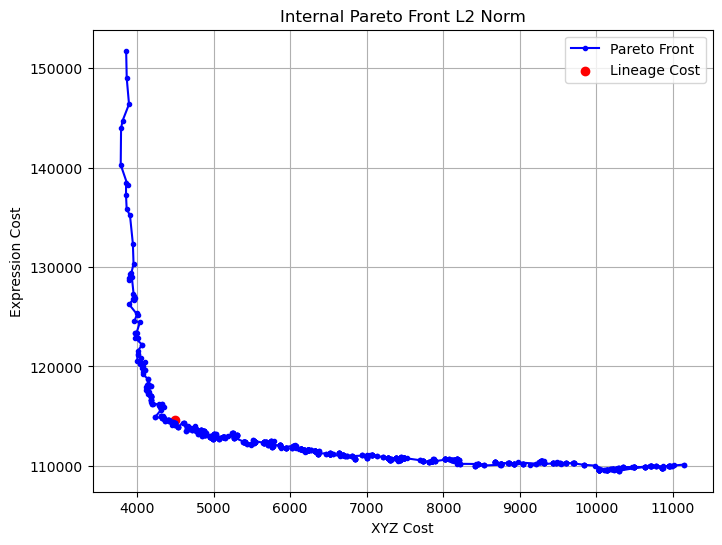

In [19]:
pareto_xyz_cost_list = [cost[0] for cost in pareto_list_layerwise]
pareto_exp_cost_list = [cost[1] for cost in pareto_list_layerwise]
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front')
plt.xlabel('XYZ Cost')
plt.ylabel('Expression Cost')
plt.scatter(lineage_xyz_cost, lineage_exp_cost, color='red', label='Lineage Cost')
plt.title(f'Internal Pareto Front L2 Norm')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
bottom_start = set()
for node in all_terminal_nodes:
    to_add = True
    for child in node.parent.children:
        if not child.optimized:
            to_add = False
            break
    if to_add:
        bottom_start.add(node.parent)

bottom_start = list(bottom_start)


In [20]:
def single_step_optimization(idx):
    alpha = 0 + 0.001 * idx  # weight for xyz cost
    candidate_pool = all_internal_pool_idx.copy() + all_internal_front_idx.copy()
    candidate_pool = [all_nodes[i] for i in candidate_pool]
    parent_openings = bottom_start.copy()
    best_candidate_idx = 0
    best_node_idx = 0
    while len(candidate_pool) > 0:
        # print(len(candidate_pool), len(parent_openings))
        min_cost = float('inf')
        for i, node in enumerate(parent_openings):
            for j, candidate in enumerate(candidate_pool):
                child_xyz_cost = 0
                child_exp_cost = 0
                for child in node.children:
                    child_xyz_cost += all_xyz_cost_map[child.key][candidate]
                    child_exp_cost += all_exp_cost_map[child.key][candidate]
                cur_cost = alpha * child_xyz_cost + (1 - alpha) * child_exp_cost
                cur_cost = cur_cost / len(node.children)
                if cur_cost < min_cost:
                    min_cost = cur_cost
                    best_candidate_idx = j
                    best_node_idx = i
        parent_openings[best_node_idx].key = candidate_pool[best_candidate_idx]
        parent_openings[best_node_idx].coordinate = coordinate_map[candidate_pool[best_candidate_idx]]
        parent_openings[best_node_idx].exp_data = exp_data_map[candidate_pool[best_candidate_idx]]
        parent_openings[best_node_idx].optimized = True
        next_parent = parent_openings[best_node_idx].parent
        del candidate_pool[best_candidate_idx]
        del parent_openings[best_node_idx]
        if next_parent.optimized:
            continue
        to_add = True
        for child in next_parent.children:
            if not child.optimized:
                to_add = False
                break
        if to_add:
            parent_openings.append(next_parent)
    cost_q = deque(internal_front)
    total_xyz_cost = 0
    total_exp_cost = 0
    while len(cost_q) > 0:
        cur_node = cost_q.popleft()
        if not cur_node.is_terminal and not cur_node.is_top:
            cur_node.optimized = False
        for child in cur_node.children:
            cost_q.append(child)
            total_xyz_cost += np.linalg.norm(cur_node.coordinate - child.coordinate)
            total_exp_cost += np.linalg.norm(cur_node.exp_data - child.exp_data)
    return total_xyz_cost, total_exp_cost

In [21]:
single_step_optimization(0)

(np.float64(12794.578933183082), np.float64(117086.85124647338))

In [21]:
pareto_list_stepwise = process_map(
    single_step_optimization,
    range(1001),
    max_workers=10,
    chunksize=50,
    desc="Computing pareto costs"
)

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

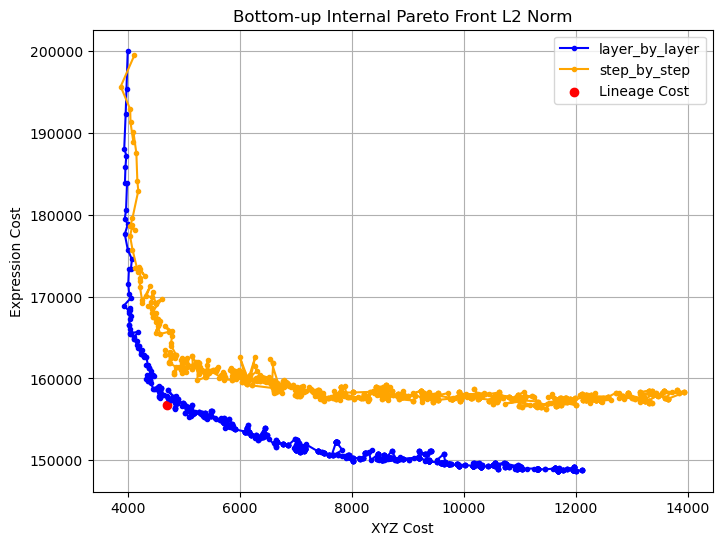

In [22]:
pareto_xyz_cost_list_layerwise = [cost[0] for cost in pareto_list_layerwise]
pareto_exp_cost_list_layerwise = [cost[1] for cost in pareto_list_layerwise]
pareto_xyz_cost_list_stepwise = [cost[0] for cost in pareto_list_stepwise]
pareto_exp_cost_list_stepwise = [cost[1] for cost in pareto_list_stepwise]
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_layerwise, pareto_exp_cost_list_layerwise, marker='o', linestyle='-', color='blue', markersize=3, label='layer_by_layer')
plt.plot(pareto_xyz_cost_list_stepwise, pareto_exp_cost_list_stepwise, marker='o', linestyle='-', color='orange', markersize=3, label='step_by_step')
plt.xlabel('XYZ Cost')
plt.ylabel('Expression Cost')
plt.scatter(lineage_xyz_cost, lineage_exp_cost, color='red', label='Lineage Cost')
plt.title(f'Bottom-up Internal Pareto Front L2 Norm')
plt.grid(True)
plt.legend()
plt.show()

In [39]:
def top_down_rebuild(idx):
    alpha = 0 + 0.001 * idx  # weight for xyz cost
    edge_count = 0
    all_cost_mat = alpha * all_xyz_cost_mat + (1 - alpha) * all_exp_cost_mat
    candidate_pool = all_internal_pool_idx.copy()
    parent_node_list = all_internal_front_idx.copy()
    cost_pq = []
    children_count = {}
    for i in parent_node_list:
        children_count[i] = 0
        for j in candidate_pool:
            heapq.heappush(cost_pq, (all_cost_mat[i][j], i, j))

    total_exp_cost = 0
    total_xyz_cost = 0

    while candidate_pool:
        if len(cost_pq) == 0:
            break
        cur_cost, parent_idx, child_idx = heapq.heappop(cost_pq)
        if children_count[parent_idx] >= 2:
            continue
        if child_idx not in candidate_pool:
            continue
        children_count[parent_idx] += 1
        total_xyz_cost += all_xyz_cost_mat[parent_idx][child_idx]
        total_exp_cost += all_exp_cost_mat[parent_idx][child_idx]
        edge_count += 1
        candidate_pool.remove(child_idx)
        children_count[child_idx] = 0
        for i in candidate_pool:
            heapq.heappush(cost_pq, (all_cost_mat[child_idx][i], child_idx, i))
    terminal_parents_list = []
    for i, count in children_count.items():
        j = count
        while j < 2:
            terminal_parents_list.append(i)
            j += 1
    
    terminal_cost_mat = np.zeros((len(all_terminal_idx), len(terminal_parents_list)))
    terminal_xyz_cost_mat = np.zeros((len(all_terminal_idx), len(terminal_parents_list)))
    terminal_exp_cost_mat = np.zeros((len(all_terminal_idx), len(terminal_parents_list)))
    for i, i_idx_val in enumerate(all_terminal_idx):
        for j, j_idx_val in enumerate(terminal_parents_list):
            terminal_cost_mat[i][j] = all_cost_mat[i_idx_val][j_idx_val]
            terminal_xyz_cost_mat[i][j] = all_xyz_cost_mat[i_idx_val][j_idx_val]
            terminal_exp_cost_mat[i][j] = all_exp_cost_mat[i_idx_val][j_idx_val]
    row_indices, col_indices = linear_sum_assignment(terminal_cost_mat)
    total_xyz_cost += np.sum(terminal_xyz_cost_mat[row_indices, col_indices])
    total_exp_cost += np.sum(terminal_exp_cost_mat[row_indices, col_indices])

    return total_xyz_cost, total_exp_cost


In [40]:
top_down_rebuild(0)

(np.float64(10570.923243775826), np.float64(97773.75575531504))

In [41]:
pareto_list_rebuild = process_map(
    top_down_rebuild,
    range(1001),
    max_workers=10,
    chunksize=20,
    desc="Computing pareto costs"
)

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

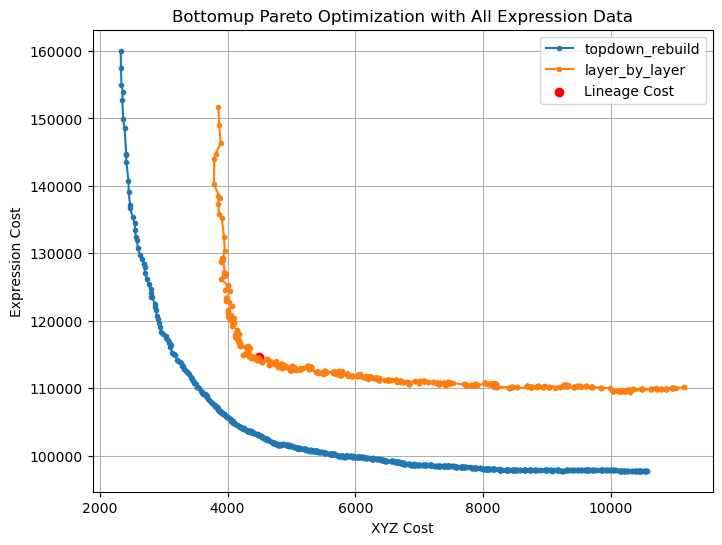

In [46]:
pareto_xyz_cost_list = [cost[0]  for cost in pareto_list_rebuild]
pareto_exp_cost_list = [cost[1] for cost in pareto_list_rebuild]
pareto_xyz_cost_list_layerwise = [cost[0] for cost in pareto_list_layerwise]
pareto_exp_cost_list_layerwise = [cost[1] for cost in pareto_list_layerwise]
# pareto_xyz_cost_list_stepwise = [cost[0] for cost in pareto_list_stepwise]
# pareto_exp_cost_list_stepwise = [cost[1] for cost in pareto_list_stepwise]
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list, marker='o', linestyle='-', markersize=3, label='topdown_rebuild')
plt.plot(pareto_xyz_cost_list_layerwise, pareto_exp_cost_list_layerwise, marker='o', linestyle='-', markersize=3, label='layer_by_layer')
# plt.plot(pareto_xyz_cost_list_stepwise, pareto_exp_cost_list_stepwise, marker='o', linestyle='-', markersize=3, label='step_by_step')
plt.xlabel('XYZ Cost')
plt.ylabel('Expression Cost')
plt.scatter(lineage_xyz_cost, lineage_exp_cost, color='red', label='Lineage Cost')
plt.title(f'Bottomup Pareto Optimization with All Expression Data')
plt.grid(True)
plt.legend()
plt.show()

In [26]:
# save pareto_list_layerwise, pareto_list_stepwise, pareto_list_rebuild and random_cost_list in npy array formatd
np.save('output/internal_opt/tenth_binned_253_3d_l2/pareto_list_layerwise.npy', pareto_list_layerwise)
np.save('output/internal_opt/tenth_binned_253_3d_l2/pareto_list_stepwise.npy', pareto_list_stepwise)
np.save('output/internal_opt/tenth_binned_253_3d_l2/pareto_list_rebuild.npy', pareto_list_rebuild)
np.save('output/internal_opt/tenth_binned_253_3d_l2/random_cost_list.npy', random_cost_list)

In [13]:
def bottom_up_rebuild(idx):
    alpha = 0 + 0.001 * idx  # weight for xyz cost
    all_cost_mat = alpha * all_xyz_cost_mat + (1 - alpha) * all_exp_cost_mat
    candidate_pool = all_internal_pool_idx.copy() + all_internal_front_idx.copy()
    children_list = all_terminal_idx.copy()
    total_xyz_cost = 0
    total_exp_cost = 0
    edge_count = 0
    while candidate_pool:
        children_edges = []
        for i in range(len(children_list)):
            for j in range(i+1, len(children_list)):
                children_edges.append((children_list[i], children_list[j], all_cost_mat[children_list[i]][children_list[j]]))
        G = nx.Graph()
        G.add_weighted_edges_from(children_edges)
        children_pairs = list(nx.min_weight_matching(G))
        next_children_list = []
        if len(children_list) % 2 == 1:
            flatten_res = [item for sublist in children_pairs for item in sublist]
            unpaired_child = list(set(children_list) - set(flatten_res))[0]
            next_children_list.append(unpaired_child)
        cur_cost_mat = np.zeros((len(candidate_pool), len(children_pairs)))
        for i in range(len(candidate_pool)):
            for j, (node1, node2) in enumerate(children_pairs):
                cur_cost_mat[i][j] = all_cost_mat[candidate_pool[i]][node1] + all_cost_mat[candidate_pool[i]][node2]
        row_indices, col_indices = linear_sum_assignment(cur_cost_mat)
        for row, col in zip(row_indices, col_indices):
            child_1, child_2 = children_pairs[col]
            total_xyz_cost += all_xyz_cost_mat[candidate_pool[row]][child_1] + all_xyz_cost_mat[candidate_pool[row]][child_2]
            total_exp_cost += all_exp_cost_mat[candidate_pool[row]][child_1] + all_exp_cost_mat[candidate_pool[row]][child_2]
            next_children_list.append(candidate_pool[row])
            edge_count += 2
        for i in row_indices[::-1]:
            del candidate_pool[i]
        children_list = next_children_list
    return total_xyz_cost, total_exp_cost

    

In [14]:
bottom_up_rebuild(0)

(np.float64(11208.52159322671), np.float64(106311.47441632219))

In [15]:
bottom_up_rebuild(999)

(np.float64(3109.458605863011), np.float64(157758.93131259677))

In [48]:
pareto_list_bottom_up_rebuild = process_map(
    bottom_up_rebuild,
    range(1001),
    max_workers=10,
    chunksize=20,
    desc="Computing pareto costs, this is gonna take a loooooooong while..."
)

Computing pareto costs, this is gonna take a loooooooong while...:   0%|          | 0/1001 [00:00<?, ?it/s]

In [30]:
np.save('output/internal_opt/tenth_binned_253_3d_l2/pareto_list_bottom_up_rebuild.npy', pareto_list_bottom_up_rebuild)

In [31]:
# pareto_list_layerwise = np.load('output/internal_opt/tenth_binned_231_3d_l2/pareto_list_layerwise.npy')
# pareto_list_stepwise = np.load('output/internal_opt/tenth_binned_231_3d_l2/pareto_list_stepwise.npy')
# pareto_list_rebuild = np.load('output/internal_opt/tenth_binned_231_3d_l2/pareto_list_rebuild.npy')
# pareto_list_bottom_up_rebuild = np.load('output/internal_opt/tenth_binned_231_3d_l2/pareto_list_bottom_up_rebuild.npy')
# random_cost_list = np.load('output/internal_opt/tenth_binned_231_3d_l2/random_cost_list.npy')

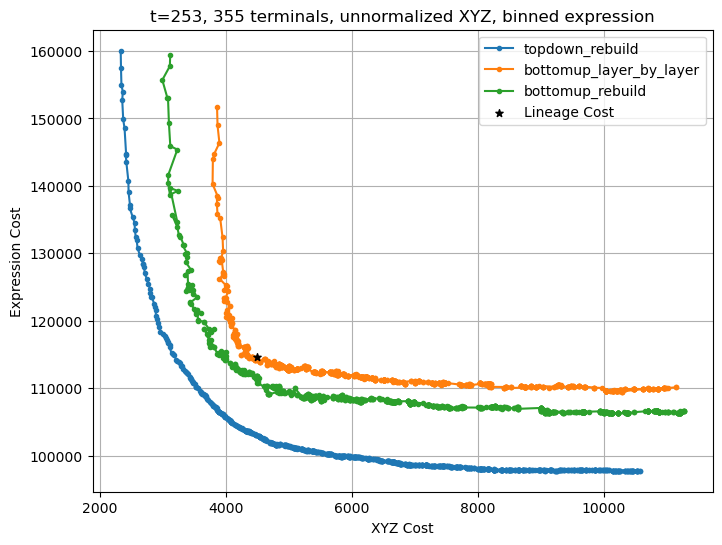

In [49]:
rebuild_pareto_xyz_cost_list = [cost[0] for cost in pareto_list_rebuild]
rebuild_pareto_exp_cost_list = [cost[1] for cost in pareto_list_rebuild]
pareto_xyz_cost_list_layerwise = [cost[0] for cost in pareto_list_layerwise]
pareto_exp_cost_list_layerwise = [cost[1] for cost in pareto_list_layerwise]
# pareto_xyz_cost_list_stepwise = [cost[0] for cost in pareto_list_stepwise]
# pareto_exp_cost_list_stepwise = [cost[1] for cost in pareto_list_stepwise]
pareto_xyz_cost_list = [cost[0] for cost in pareto_list_bottom_up_rebuild]
pareto_exp_cost_list = [cost[1] for cost in pareto_list_bottom_up_rebuild]
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(rebuild_pareto_xyz_cost_list, rebuild_pareto_exp_cost_list, marker='o', linestyle='-', markersize=3, label='topdown_rebuild')
plt.plot(pareto_xyz_cost_list_layerwise, pareto_exp_cost_list_layerwise, marker='o', linestyle='-', markersize=3, label='bottomup_layer_by_layer')
# plt.plot(pareto_xyz_cost_list_stepwise, pareto_exp_cost_list_stepwise, marker='o', linestyle='-', markersize=3, label='bottomup_step_by_step')
plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list, marker='o', linestyle='-', markersize=3, label='bottomup_rebuild')
plt.xlabel('XYZ Cost')
plt.ylabel('Expression Cost')
plt.scatter(lineage_xyz_cost, lineage_exp_cost, marker='*', s=30, color='black', label='Lineage Cost', zorder=10)
plt.title(f't=253, 355 terminals, unnormalized XYZ, binned expression')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# to be continued...
# def unbalanced_bottom_up_rebuild(idx):
#     alpha = 0 + 0.001 * idx  # weight for xyz cost
#     all_cost_mat = alpha * all_xyz_cost_mat + (1 - alpha) * all_exp_cost_mat
#     candidate_pool = all_internal_pool_idx.copy() + all_internal_front_idx.copy()
#     candidate_pool = candidate_pool + candidate_pool
#     children_list = all_terminal_idx.copy()
#     total_xyz_cost = 0
#     total_exp_cost = 0
#     edge_count = 0
#     while candidate_pool:
#         cur_cost_mat = np.zeros((len(candidate_pool), len(children_list)))
#         for i in range(len(candidate_pool)):
#             for j in range(len(children_list)):
#                 cur_cost_mat[i][j] = all_cost_mat[candidate_pool[i]][children_list[j]]
#         row_indices, col_indices = linear_sum_assignment(cur_cost_mat)
#         next_children_list = []
#         for row, col in zip(row_indices, col_indices):
#     return total_xyz_cost, total_exp_cost

    

IndentationError: expected an indented block after 'for' statement on line 17 (4116258218.py, line 18)